# Image Segmentation with CellPose
CellPose is a deep-learning based segmentation algorithm for cells and nuclei in microscopy images. It comes with pretrained models we demonstrate in this notebook. It is meant to be executed in Google Colab.

See also
* [Cellpose in Nature Methods](https://www.nature.com/articles/s41592-020-01018-x)
* [Cellpose on github](https://github.com/MouseLand/cellpose)
* [Cellpose example notebook](https://github.com/MouseLand/cellpose/blob/master/notebooks/run_cellpose.ipynb)




**Cellpose-SAM segmentation for:**
1) 2D_image_nuclei_cells_liver.tif
    - channel 2 = membranes
    - channel 3 = nuclei

2) Multi_color_3D.tif
    - channel 1 = membranes
    - channel 2 = nuclei

 Segments:
 - nuclei
 - cells
 and visualizes the results
 ===========================================================

In [1]:
!pip install -q "cellpose>=4" tifffile stackview ipycanvas==0.11

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.8/255.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.1/213.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.5 MB/s eta 0:00:00


In [2]:
import stackview
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

from skimage.segmentation import find_boundaries
from cellpose import models

Raw GitHub URLs


In [3]:
img2d_path = (
    "https://raw.githubusercontent.com/"
    "BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/main/images/"
    "2D_image_nuclei_cells_liver.tif"
)

img3d_path = (
    "https://raw.githubusercontent.com/"
    "BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/main/images/"
    "Multi_color_3D.tif"
)

Helper functions

In [4]:
from skimage.io import imread

def load_tiff(path_or_url):
    """Load TIFF from local path or URL."""
    return imread(path_or_url)


def ensure_channel_first_2d(img):
    """
    Convert a 2D multichannel image to (C, Y, X).

    Accepts:
    - (C, Y, X)
    - (Y, X, C)
    """
    if img.ndim != 3:
        raise ValueError(f"Expected 3D array for 2D multichannel image, got shape={img.shape}")

    # If first axis looks like channels
    if img.shape[0] <= 6:
        return img

    # If last axis looks like channels
    if img.shape[-1] <= 6:
        return np.moveaxis(img, -1, 0)

    raise ValueError(
        f"Could not infer channel axis for 2D image with shape={img.shape}. "
        "Please inspect the TIFF layout."
    )


def ensure_channel_first_3d(img):
    """
    Convert a 3D multichannel volume to (C, Z, Y, X).

    Accepts common layouts:
    - (C, Z, Y, X)
    - (Z, Y, X, C)
    - (Z, C, Y, X)
    """
    if img.ndim != 4:
        raise ValueError(f"Expected 4D array for 3D multichannel image, got shape={img.shape}")

    # channel-first already
    if img.shape[0] <= 6:
        return img

    # channel-last
    if img.shape[-1] <= 6:
        return np.moveaxis(img, -1, 0)

    # Z, C, Y, X
    if img.shape[1] <= 6:
        return np.moveaxis(img, 1, 0)

    raise ValueError(
        f"Could not infer channel axis for 3D image with shape={img.shape}. "
        "Please inspect the TIFF layout."
    )


def normalize_percentile(x, p_low=1, p_high=99.8):
    """Percentile normalization to [0, 1]."""
    x = x.astype(np.float32)
    lo = np.percentile(x, p_low)
    hi = np.percentile(x, p_high)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip((x - lo) / (hi - lo), 0, 1)
    return x


def make_2d_cellpose_input(membrane, nuclei):
    """
    Build a 3-channel 2D image for Cellpose-SAM.
    Channel order is flexible for Cellpose-SAM, but here we use:
    [membrane, nuclei, 0]
    Output shape: (Y, X, 3)
    """
    membrane = normalize_percentile(membrane)
    nuclei = normalize_percentile(nuclei)
    zero = np.zeros_like(membrane, dtype=np.float32)
    return np.stack([membrane, nuclei, zero], axis=-1)


def make_2d_nuc_input(nuclei):
    """
    Build a nuclei-focused 3-channel input:
    [nuclei, 0, 0]
    """
    nuclei = normalize_percentile(nuclei)
    zero = np.zeros_like(nuclei, dtype=np.float32)
    return np.stack([nuclei, zero, zero], axis=-1)


def make_3d_cellpose_input(membrane, nuclei):
    """
    Build a 3-channel 3D image for Cellpose-SAM.
    Input membrane, nuclei shape: (Z, Y, X)
    Output shape: (Z, Y, X, 3)
    """
    membrane = normalize_percentile(membrane)
    nuclei = normalize_percentile(nuclei)
    zero = np.zeros_like(membrane, dtype=np.float32)
    return np.stack([membrane, nuclei, zero], axis=-1)


def make_3d_nuc_input(nuclei):
    """
    Build a nuclei-focused 3-channel 3D input:
    [nuclei, 0, 0]
    Output shape: (Z, Y, X, 3)
    """
    nuclei = normalize_percentile(nuclei)
    zero = np.zeros_like(nuclei, dtype=np.float32)
    return np.stack([nuclei, zero, zero], axis=-1)


def overlay_boundaries(gray_img, labels, color=(1, 0, 0)):
    """
    Overlay segmentation boundaries on a grayscale image.
    gray_img expected in [0,1].
    """
    rgb = np.dstack([gray_img, gray_img, gray_img]).copy()
    b = find_boundaries(labels, mode="outer")
    rgb[b] = color
    return rgb


def max_projection(vol):
    """Max projection of a 3D volume (Z, Y, X) along Z."""
    return vol.max(axis=0)


def max_projection_labels(lbl):
    """
    Simple visualization MIP for labels.
    Not a true instance-preserving projection, but useful for display.
    """
    return lbl.max(axis=0)


Load model

In [40]:
# Cellpose-SAM is the default pretrained model in CellposeModel. :contentReference[oaicite:1]{index=1}
model = models.CellposeModel(gpu=True, pretrained_model="cpsam")


# *Segment* 2D IMAGE

In [7]:
img2d = load_tiff(img2d_path)
img2d_cf = ensure_channel_first_2d(img2d)

print("2D image original shape:", img2d.shape)
print("2D image channel-first shape:", img2d_cf.shape)

# User-specified channels:
# channel 2 = membranes, channel 3 = nuclei
# zero-based indexing: membrane=1, nuclei=2
mem2d = img2d_cf[1]
nuc2d = img2d_cf[2]

img2d_cells = make_2d_cellpose_input(mem2d, nuc2d)
img2d_nuclei = make_2d_nuc_input(nuc2d)

2D image original shape: (694, 786, 3)
2D image channel-first shape: (3, 694, 786)


In [9]:
# Segment nuclei
masks_nuc_2d, flows_nuc_2d, styles_nuc_2d = model.eval(
    img2d_nuclei,
    diameter=None,
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=20
)

In [10]:
# Segment whole cells
masks_cell_2d, flows_cell_2d, styles_cell_2d = model.eval(
    img2d_cells,
    diameter=None,
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=50
)

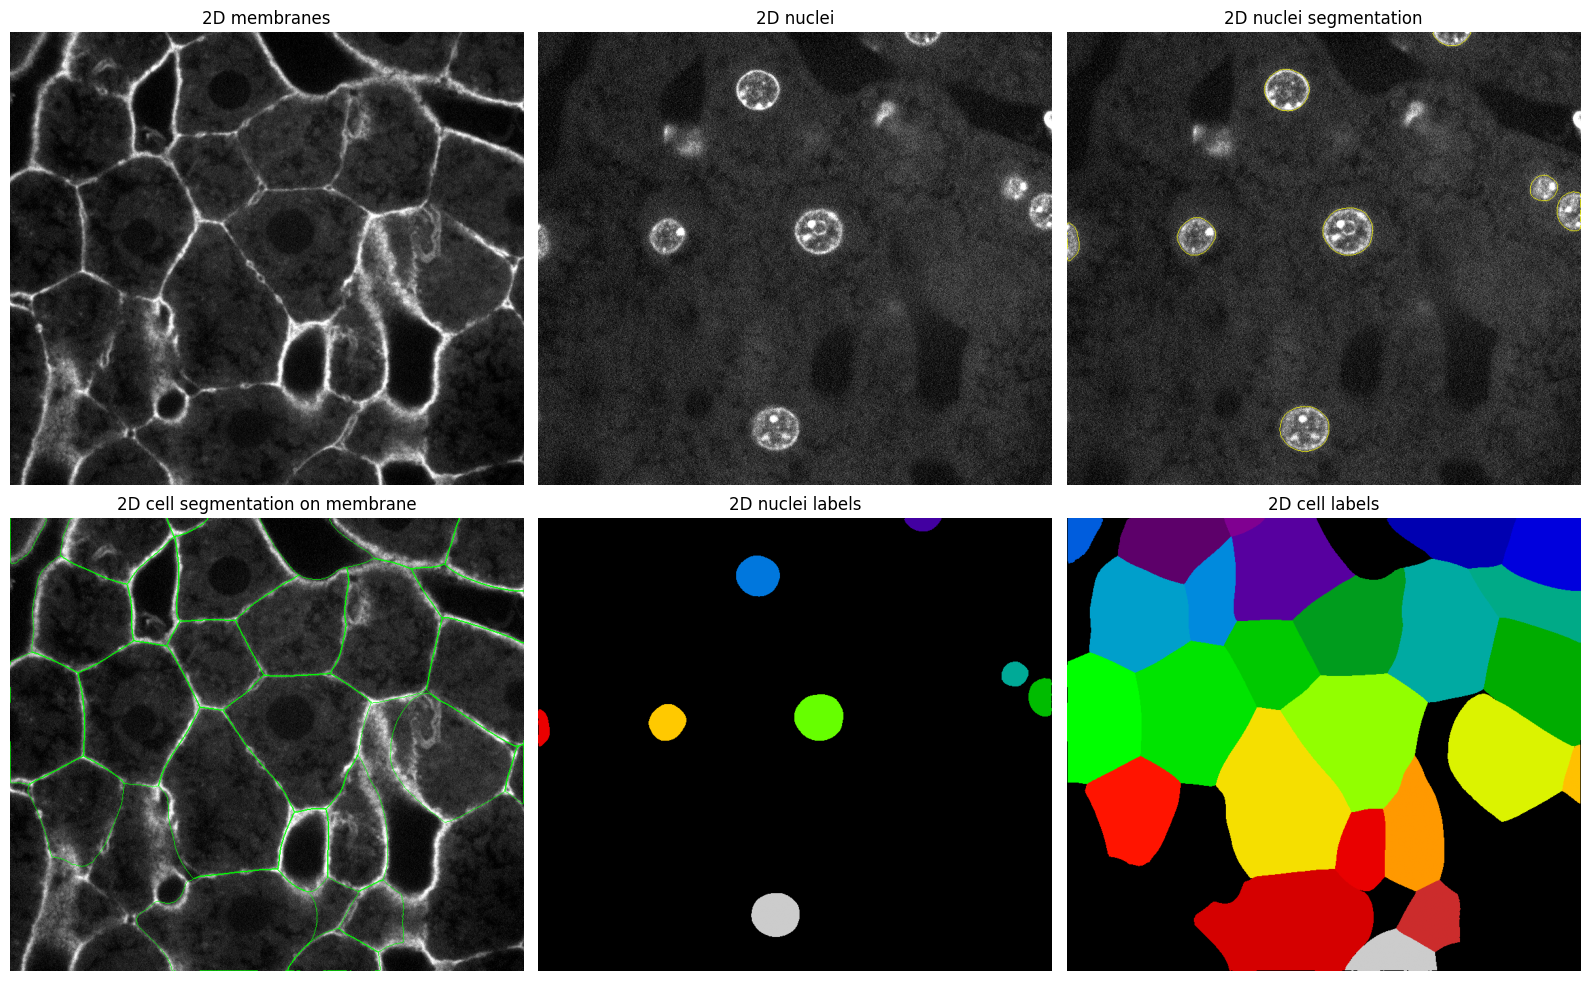

2D nuclei objects: 8
2D cell objects:   25


In [12]:
# Visualize 2D
mem2d_n = normalize_percentile(mem2d)
nuc2d_n = normalize_percentile(nuc2d)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(mem2d_n, cmap="gray")
axes[0, 0].set_title("2D membranes")
axes[0, 0].axis("off")

axes[0, 1].imshow(nuc2d_n, cmap="gray")
axes[0, 1].set_title("2D nuclei")
axes[0, 1].axis("off")

axes[0, 2].imshow(overlay_boundaries(nuc2d_n, masks_nuc_2d, color=(1, 1, 0)))
axes[0, 2].set_title("2D nuclei segmentation")
axes[0, 2].axis("off")

axes[1, 0].imshow(overlay_boundaries(mem2d_n, masks_cell_2d, color=(0, 1, 0)))
axes[1, 0].set_title("2D cell segmentation on membrane")
axes[1, 0].axis("off")

axes[1, 1].imshow(masks_nuc_2d, cmap="nipy_spectral")
axes[1, 1].set_title("2D nuclei labels")
axes[1, 1].axis("off")

axes[1, 2].imshow(masks_cell_2d, cmap="nipy_spectral")
axes[1, 2].set_title("2D cell labels")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"2D nuclei objects: {masks_nuc_2d.max()}")
print(f"2D cell objects:   {masks_cell_2d.max()}")

In [13]:
# *Segment* 3D IMAGE

In [38]:
img3d = load_tiff(img3d_path)

img3d = img3d[:, :, :50, :50]

img3d_cf = ensure_channel_first_3d(img3d)



print("3D image original shape:", img3d.shape)
print("3D image channel-first shape:", img3d_cf.shape)

# User-specified channels:
# channel 1 = membranes, channel 2 = nuclei
# zero-based indexing: membrane=0, nuclei=1
mem3d = img3d_cf[0]   # (Z, Y, X)
nuc3d = img3d_cf[1]   # (Z, Y, X)

img3d_cells = make_3d_cellpose_input(mem3d, nuc3d)   # (Z, Y, X, 3)
img3d_nuclei = make_3d_nuc_input(nuc3d)              # (Z, Y, X, 3)



print("3D image shape:", img3d_nuclei.shape)

3D image original shape: (45, 2, 50, 50)
3D image channel-first shape: (2, 45, 50, 50)
3D image shape: (45, 50, 50, 3)


In [41]:
# Segment nuclei in 3D
masks_nuc_3d, flows_nuc_3d, styles_nuc_3d = model.eval(
    img3d_nuclei,
    diameter=None,
    do_3D=True,
    z_axis=0,
    channel_axis=3,
    anisotropy=1.0,   # adjust if z-spacing differs from xy-spacing
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=50
)

In [42]:
# Segment cells in 3D
masks_cell_3d, flows_cell_3d, styles_cell_3d = model.eval(
    img3d_cells,
    diameter=None,
    do_3D=True,
    z_axis=0,
    channel_axis=3,
    anisotropy=1.0,   # adjust if z-spacing differs from xy-spacing
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=50
)

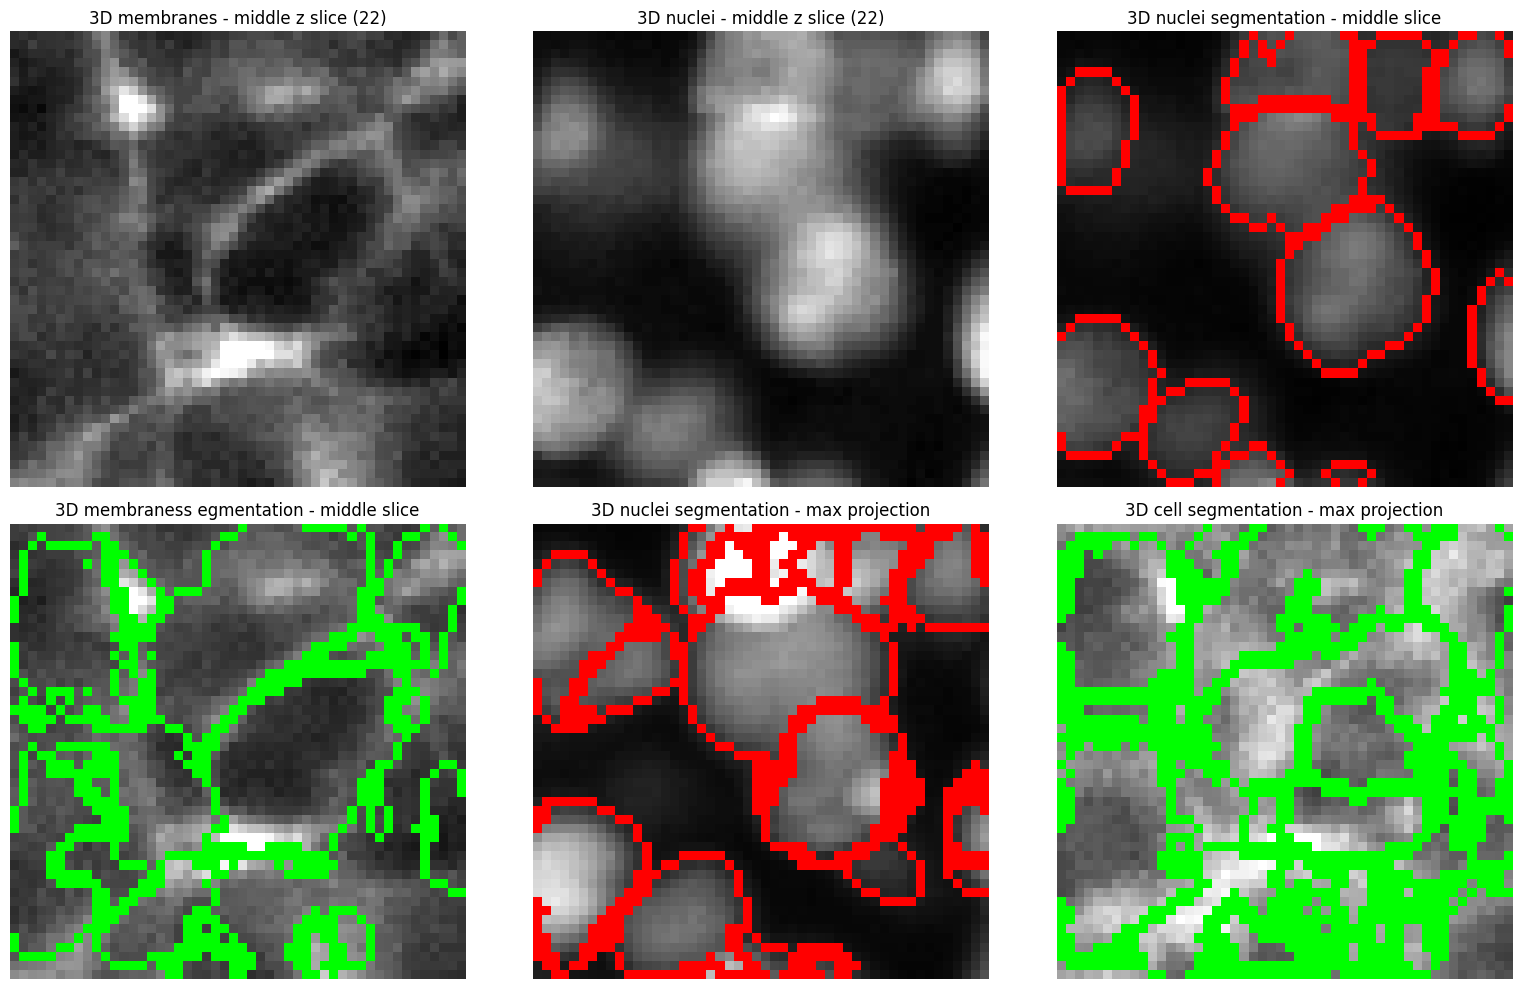

3D nuclei objects: 21
3D cell objects:   35


In [44]:
# Visualize 3D

zmid = mem3d.shape[0] // 2

mem3d_n = normalize_percentile(mem3d)
nuc3d_n = normalize_percentile(nuc3d)

mem3d_mip = max_projection(mem3d_n)
nuc3d_mip = max_projection(nuc3d_n)

# Boundary overlays on middle slice
nuc_slice_overlay = overlay_boundaries(
    nuc3d_n[zmid], masks_nuc_3d[zmid], color=(1, 0, 0)
)
cell_slice_overlay = overlay_boundaries(
    mem3d_n[zmid], masks_cell_3d[zmid], color=(0, 1, 0)
)

# Boundary overlays on max projections
nuc_mip_overlay = overlay_boundaries(
    nuc3d_mip, max_projection_labels(masks_nuc_3d), color=(1, 0, 0)
)
cell_mip_overlay = overlay_boundaries(
    mem3d_mip, max_projection_labels(masks_cell_3d), color=(0, 1, 0)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(mem3d_n[zmid], cmap="gray")
axes[0, 0].set_title(f"3D membranes - middle z slice ({zmid})")
axes[0, 0].axis("off")

axes[0, 1].imshow(nuc3d_n[zmid], cmap="gray")
axes[0, 1].set_title(f"3D nuclei - middle z slice ({zmid})")
axes[0, 1].axis("off")

axes[0, 2].imshow(nuc_slice_overlay)
axes[0, 2].set_title("3D nuclei segmentation - middle slice")
axes[0, 2].axis("off")

axes[1, 0].imshow(cell_slice_overlay, cmap="gray")
axes[1, 0].set_title("3D membraness egmentation - middle slice")
axes[1, 0].axis("off")

axes[1, 1].imshow(nuc_mip_overlay)
axes[1, 1].set_title("3D nuclei segmentation - max projection")
axes[1, 1].axis("off")

axes[1, 2].imshow(cell_mip_overlay)
axes[1, 2].set_title("3D cell segmentation - max projection")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"3D nuclei objects: {masks_nuc_3d.max()}")
print(f"3D cell objects:   {masks_cell_3d.max()}")

In [ ]:
# Optional: save results

tiff.imwrite("2D_nuclei_masks_cellposeSAM.tif", masks_nuc_2d.astype(np.uint16))
tiff.imwrite("2D_cell_masks_cellposeSAM.tif", masks_cell_2d.astype(np.uint16))
tiff.imwrite("3D_nuclei_masks_cellposeSAM.tif", masks_nuc_3d.astype(np.uint16))
tiff.imwrite("3D_cell_masks_cellposeSAM.tif", masks_cell_3d.astype(np.uint16))